In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/bimal701/cows-disease-dataset/Cows datasets/healthy/imgs477.jpg
/kaggle/input/datasets/bimal701/cows-disease-dataset/Cows datasets/healthy/HolsteinFriesiancattle61_c.jpg
/kaggle/input/datasets/bimal701/cows-disease-dataset/Cows datasets/healthy/imgs334.jpg
/kaggle/input/datasets/bimal701/cows-disease-dataset/Cows datasets/healthy/Normal_Skin_591-resized.jpg
/kaggle/input/datasets/bimal701/cows-disease-dataset/Cows datasets/healthy/imgs252.jpg
/kaggle/input/datasets/bimal701/cows-disease-dataset/Cows datasets/healthy/imgs452.jpg
/kaggle/input/datasets/bimal701/cows-disease-dataset/Cows datasets/healthy/RedDanecattle90.jpg
/kaggle/input/datasets/bimal701/cows-disease-dataset/Cows datasets/healthy/imgs313.jpg
/kaggle/input/datasets/bimal701/cows-disease-dataset/Cows datasets/healthy/Non-diseased-muzzle-27_jpg.rf.b0b87efc7055c429dfc38d7bc349041c.jpg
/kaggle/input/datasets/bimal701/cows-disease-dataset/Cows datasets/healthy/imgs049.jpg
/kaggle/input/datasets/bimal701/

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/bimal701
/kaggle/input/datasets/bimal701/cows-disease-dataset
/kaggle/input/datasets/bimal701/cows-disease-dataset/Cows datasets
/kaggle/input/datasets/bimal701/cows-disease-dataset/Cows datasets/healthy
/kaggle/input/datasets/bimal701/cows-disease-dataset/Cows datasets/foot-and-mouth
/kaggle/input/datasets/bimal701/cows-disease-dataset/Cows datasets/lumpy


In [3]:
import os

dataset_path = "/kaggle/input/datasets/bimal701/cows-disease-dataset/Cows datasets"

classes = os.listdir(dataset_path)

print("Classes:", classes)

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    print(f"{cls}: {len(os.listdir(folder))} images")

Classes: ['healthy', 'foot-and-mouth', 'lumpy']
healthy: 1291 images
foot-and-mouth: 746 images
lumpy: 1207 images


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = "/kaggle/input/datasets/bimal701/cows-disease-dataset/Cows datasets"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print(train_data.class_indices)

2026-06-07 15:22:22.273803: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780845742.509511      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780845742.573970      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780845743.096239      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780845743.096272      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780845743.096275      16 computation_placer.cc:177] computation placer alr

Found 2596 images belonging to 3 classes.
Found 648 images belonging to 3 classes.
{'foot-and-mouth': 0, 'healthy': 1, 'lumpy': 2}


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(3, activation='softmax')

])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-07 15:22:35.560653: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.5747 - loss: 0.9148 - val_accuracy: 0.7284 - val_loss: 0.7675
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.6641 - loss: 0.7654 - val_accuracy: 0.7083 - val_loss: 0.7244
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.6861 - loss: 0.7369 - val_accuracy: 0.6883 - val_loss: 0.7306
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.6945 - loss: 0.7109 - val_accuracy: 0.7392 - val_loss: 0.6730
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.6953 - loss: 0.7136 - val_accuracy: 0.7083 - val_loss: 0.7323
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.7134 - loss: 0.6667 - val_accuracy: 0.7346 - val_loss: 0.6084
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.7107 - loss: 0.6686 - val_accuracy: 0.7176 - val_loss: 0.6824
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.7408 - loss: 0.6223 - val_accuracy: 0.7500 - v

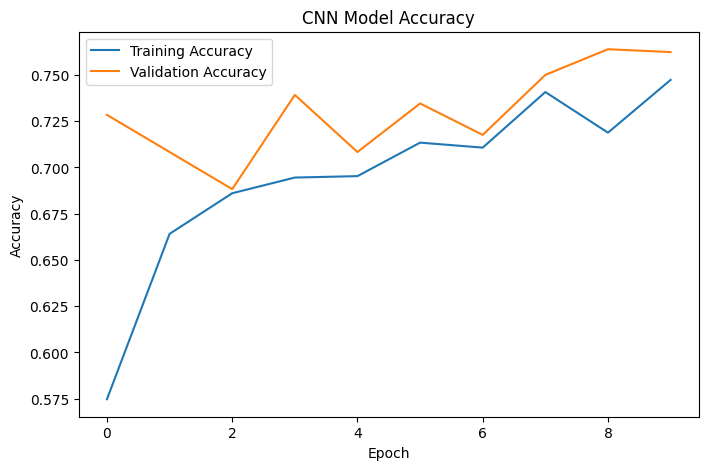

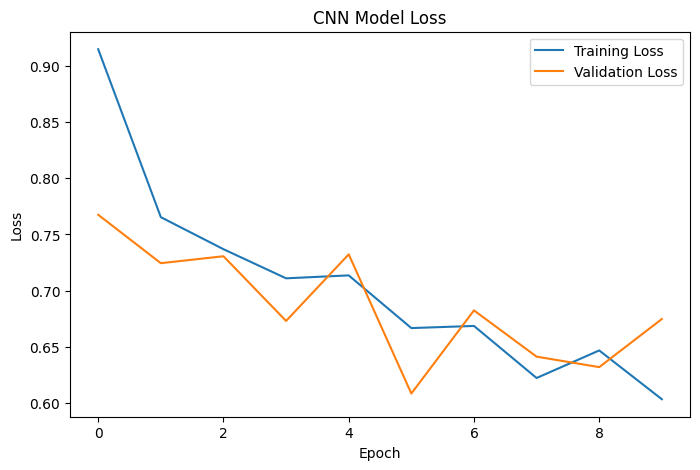

In [7]:
import matplotlib.pyplot as plt
import os

os.makedirs("/kaggle/working/outputs", exist_ok=True)

# Accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('/kaggle/working/outputs/cnn_accuracy_curve.png')
plt.show()

# Loss curve
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('/kaggle/working/outputs/cnn_loss_curve.png')
plt.show()

21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 460ms/step


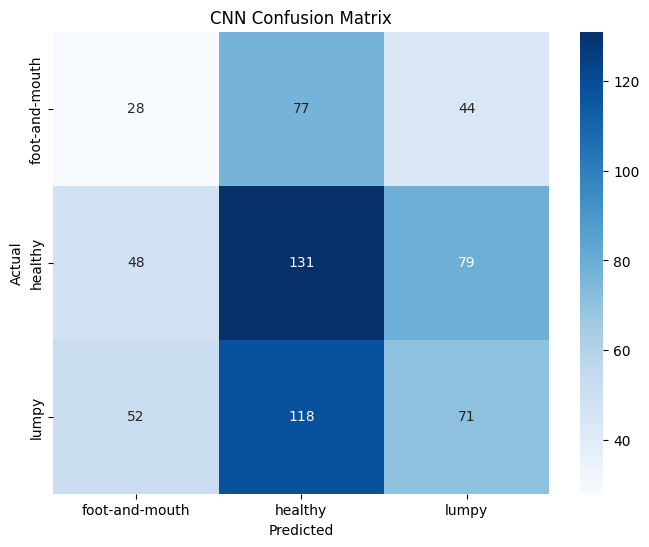

                precision    recall  f1-score   support

foot-and-mouth       0.22      0.19      0.20       149
       healthy       0.40      0.51      0.45       258
         lumpy       0.37      0.29      0.33       241

      accuracy                           0.35       648
     macro avg       0.33      0.33      0.33       648
  weighted avg       0.35      0.35      0.35       648



In [8]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Reset validation generator
val_data.reset()

# Predictions
predictions = cnn_model.predict(val_data)

y_pred = np.argmax(predictions, axis=1)
y_true = val_data.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(val_data.class_indices.keys()),
    yticklabels=list(val_data.class_indices.keys())
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print(classification_report(
    y_true,
    y_pred,
    target_names=list(val_data.class_indices.keys())
))

In [9]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

predictions = cnn_model.predict(test_data)

y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

from sklearn.metrics import confusion_matrix, classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_data.class_indices.keys())
))

Found 3244 images belonging to 3 classes.
102/102 ━━━━━━━━━━━━━━━━━━━━ 34s 332ms/step
                precision    recall  f1-score   support

foot-and-mouth       0.77      0.84      0.80       746
       healthy       0.75      0.85      0.80      1291
         lumpy       0.86      0.70      0.77      1207

      accuracy                           0.79      3244
     macro avg       0.80      0.79      0.79      3244
  weighted avg       0.80      0.79      0.79      3244



In [10]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = MobileNetV2(
    weights=None,
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

mobilenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = MobileNetV2(
    weights=None,
    include_top=False,
    input_shape=(224,224,3)
)

mobilenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 2,388,227 (9.11 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [12]:
mobilenet_history = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 228s 3s/step - accuracy: 0.5169 - loss: 1.0030 - val_accuracy: 0.3719 - val_loss: 1.0973
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 194s 2s/step - accuracy: 0.6025 - loss: 0.8798 - val_accuracy: 0.3719 - val_loss: 1.0933
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.6552 - loss: 0.8048 - val_accuracy: 0.3719 - val_loss: 1.0893
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.6683 - loss: 0.7713 - val_accuracy: 0.3719 - val_loss: 1.0915
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.6622 - loss: 0.7824 - val_accuracy: 0.3719 - val_loss: 1.0906
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.6741 - loss: 0.7641 - val_accuracy: 0.3719 - val_loss: 1.0922
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.6826 - loss: 0.7361 - val_accuracy: 0.3719 - val_loss: 1.1243
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.6818 - loss: 0.7397 - val_accuracy: 0.3719 - v

In [13]:
plt.savefig("cnn_accuracy_curve.png")
plt.savefig("cnn_loss_curve.png")

<Figure size 640x480 with 0 Axes>

In [14]:
import os

print(os.listdir("/kaggle/working/outputs"))

['cnn_accuracy_curve.png', 'cnn_loss_curve.png']


In [15]:
import os
print(os.listdir('/kaggle/working/outputs'))

['cnn_accuracy_curve.png', 'cnn_loss_curve.png']


In [16]:
import shutil

shutil.make_archive(
    '/kaggle/working/project_outputs',
    'zip',
    '/kaggle/working/outputs'
)

print("ZIP created successfully")

ZIP created successfully


In [17]:
import os
print(os.listdir('/kaggle/working'))

['cnn_accuracy_curve.png', 'cnn_loss_curve.png', 'outputs', '__notebook__.ipynb', 'project_outputs.zip']
